# Praktikum 1 Data Mining RKA (N)

**Nama:** Benedictus Ryu Gunawan

**NRP:** 5054251001

Template Kaggle Competition Praktikum Data Mining RKA.

## Setup

In [28]:
# Import Library
import os
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

ROOT_DIR = Path(os.getcwd()).parent
DATA_DIR = ROOT_DIR / "data"
SEED = 42
TARGET = "price_class"

## Load Data

In [29]:
df_train = pd.read_csv(DATA_DIR / "train.csv")
df_test = pd.read_csv(DATA_DIR / "test.csv")

df_train.index = df_train["id"]
df_test.index = df_test["id"]

df_train.drop(columns=["id"], inplace=True)
df_test.drop(columns=["id"], inplace=True)

print(f"Train Data Shape: {df_train.shape}")
print(f"Test Data Shape: {df_test.shape}")

display(df_train.head())
display(df_test.head())

Train Data Shape: (8205, 32)
Test Data Shape: (1449, 31)


,model_year,maker,model_family,trim,listing_city,listing_state,odometer_reading,body_color,cabin_color,city_mpg,...,equipment_count,has_navigation,has_backup_camera,has_bluetooth,has_heated_seats,accident_count,owner_count,commercial_use_flag,clean_title_flag,price_class
id,,,,,,,,,,,,,,,,,,,,,
749,2017,Ford,Fusion,SE FWD,Charlotte,NC,18269,Ingot Silver,Ebony,21.0,...,3,0,1,1,0,0,1,0,1,1
5410,2016,Ford,F-150,XLT SuperCrew 5.5' Box 4WD,Reading,PA,26195,Shadow Black,Black,17.0,...,7,1,1,1,1,0,1,0,1,2
2758,2019,Dodge,Journey,GT AWD,Bastrop,LA,34479,Billet Clearcoat,Black/Red,16.0,...,5,0,1,1,1,0,0,0,1,2
7088,2017,BMW,X3,xDrive28i AWD,Harriman,NY,34083,Jet Black,Black,21.0,...,0,0,0,0,0,0,1,0,1,2
6319,2015,Volkswagen,e-Golf,SEL Premium,San Diego,CA,25034,Pure White,Titan Black,126.0,...,5,1,1,1,1,0,2,0,1,1


,model_year,maker,model_family,trim,listing_city,listing_state,odometer_reading,body_color,cabin_color,city_mpg,...,turbo_flag,equipment_count,has_navigation,has_backup_camera,has_bluetooth,has_heated_seats,accident_count,owner_count,commercial_use_flag,clean_title_flag
id,,,,,,,,,,,,,,,,,,,,,
8151,2016,Maserati,GranTurismo,Sport Coupe,Tampa,FL,24955,Bianco Eldorado,Rosso Corallo,13.0,...,NaN,0,0,0,0,0,0,1,0,1
5620,2007,Land,Rover Range Rover,HSE,Marietta,GA,141920,Java Black,Black,12.0,...,NaN,0,0,0,0,0,1,4,1,1
12,2012,Subaru,Outback,2.5i Premium Auto,Moon Township,PA,134502,Ice Silver Metallic,Off-Black,22.0,...,NaN,3,0,0,1,1,0,2,0,1
8027,2004,Jaguar,X-TYPE,3.0L Automatic,Glendora,CA,38638,Silver,Black,18.0,...,NaN,0,0,0,0,0,0,2,0,1
2450,2018,Ford,F-150,XLT SuperCrew 5.5' Box 4WD,Mesquite,TX,23931,Black Velvet,Medium Light Camel,16.0,...,NaN,3,0,1,1,0,0,1,0,1


In [30]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8205 entries, 749 to 6076
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   model_year                    8205 non-null   int64  
 1   maker                         8205 non-null   object 
 2   model_family                  8205 non-null   object 
 3   trim                          8112 non-null   object 
 4   listing_city                  8205 non-null   object 
 5   listing_state                 8205 non-null   object 
 6   odometer_reading              8205 non-null   int64  
 7   body_color                    7980 non-null   object 
 8   cabin_color                   8000 non-null   object 
 9   city_mpg                      7681 non-null   float64
 10  highway_mpg                   7672 non-null   float64
 11  engine_spec                   8125 non-null   object 
 12  gearbox                       8205 non-null   object 
 13  drive_

In [31]:
print(f"Duplicate Rows in Train Data: {df_train.duplicated().sum()}")
df_train.drop_duplicates(inplace=True)


Duplicate Rows in Train Data: 2


## Exploratory Data Analysis

Lengkapi bagian ini sesuai dengan **EDA** yang kalian lakukan.

## Missing Analysis

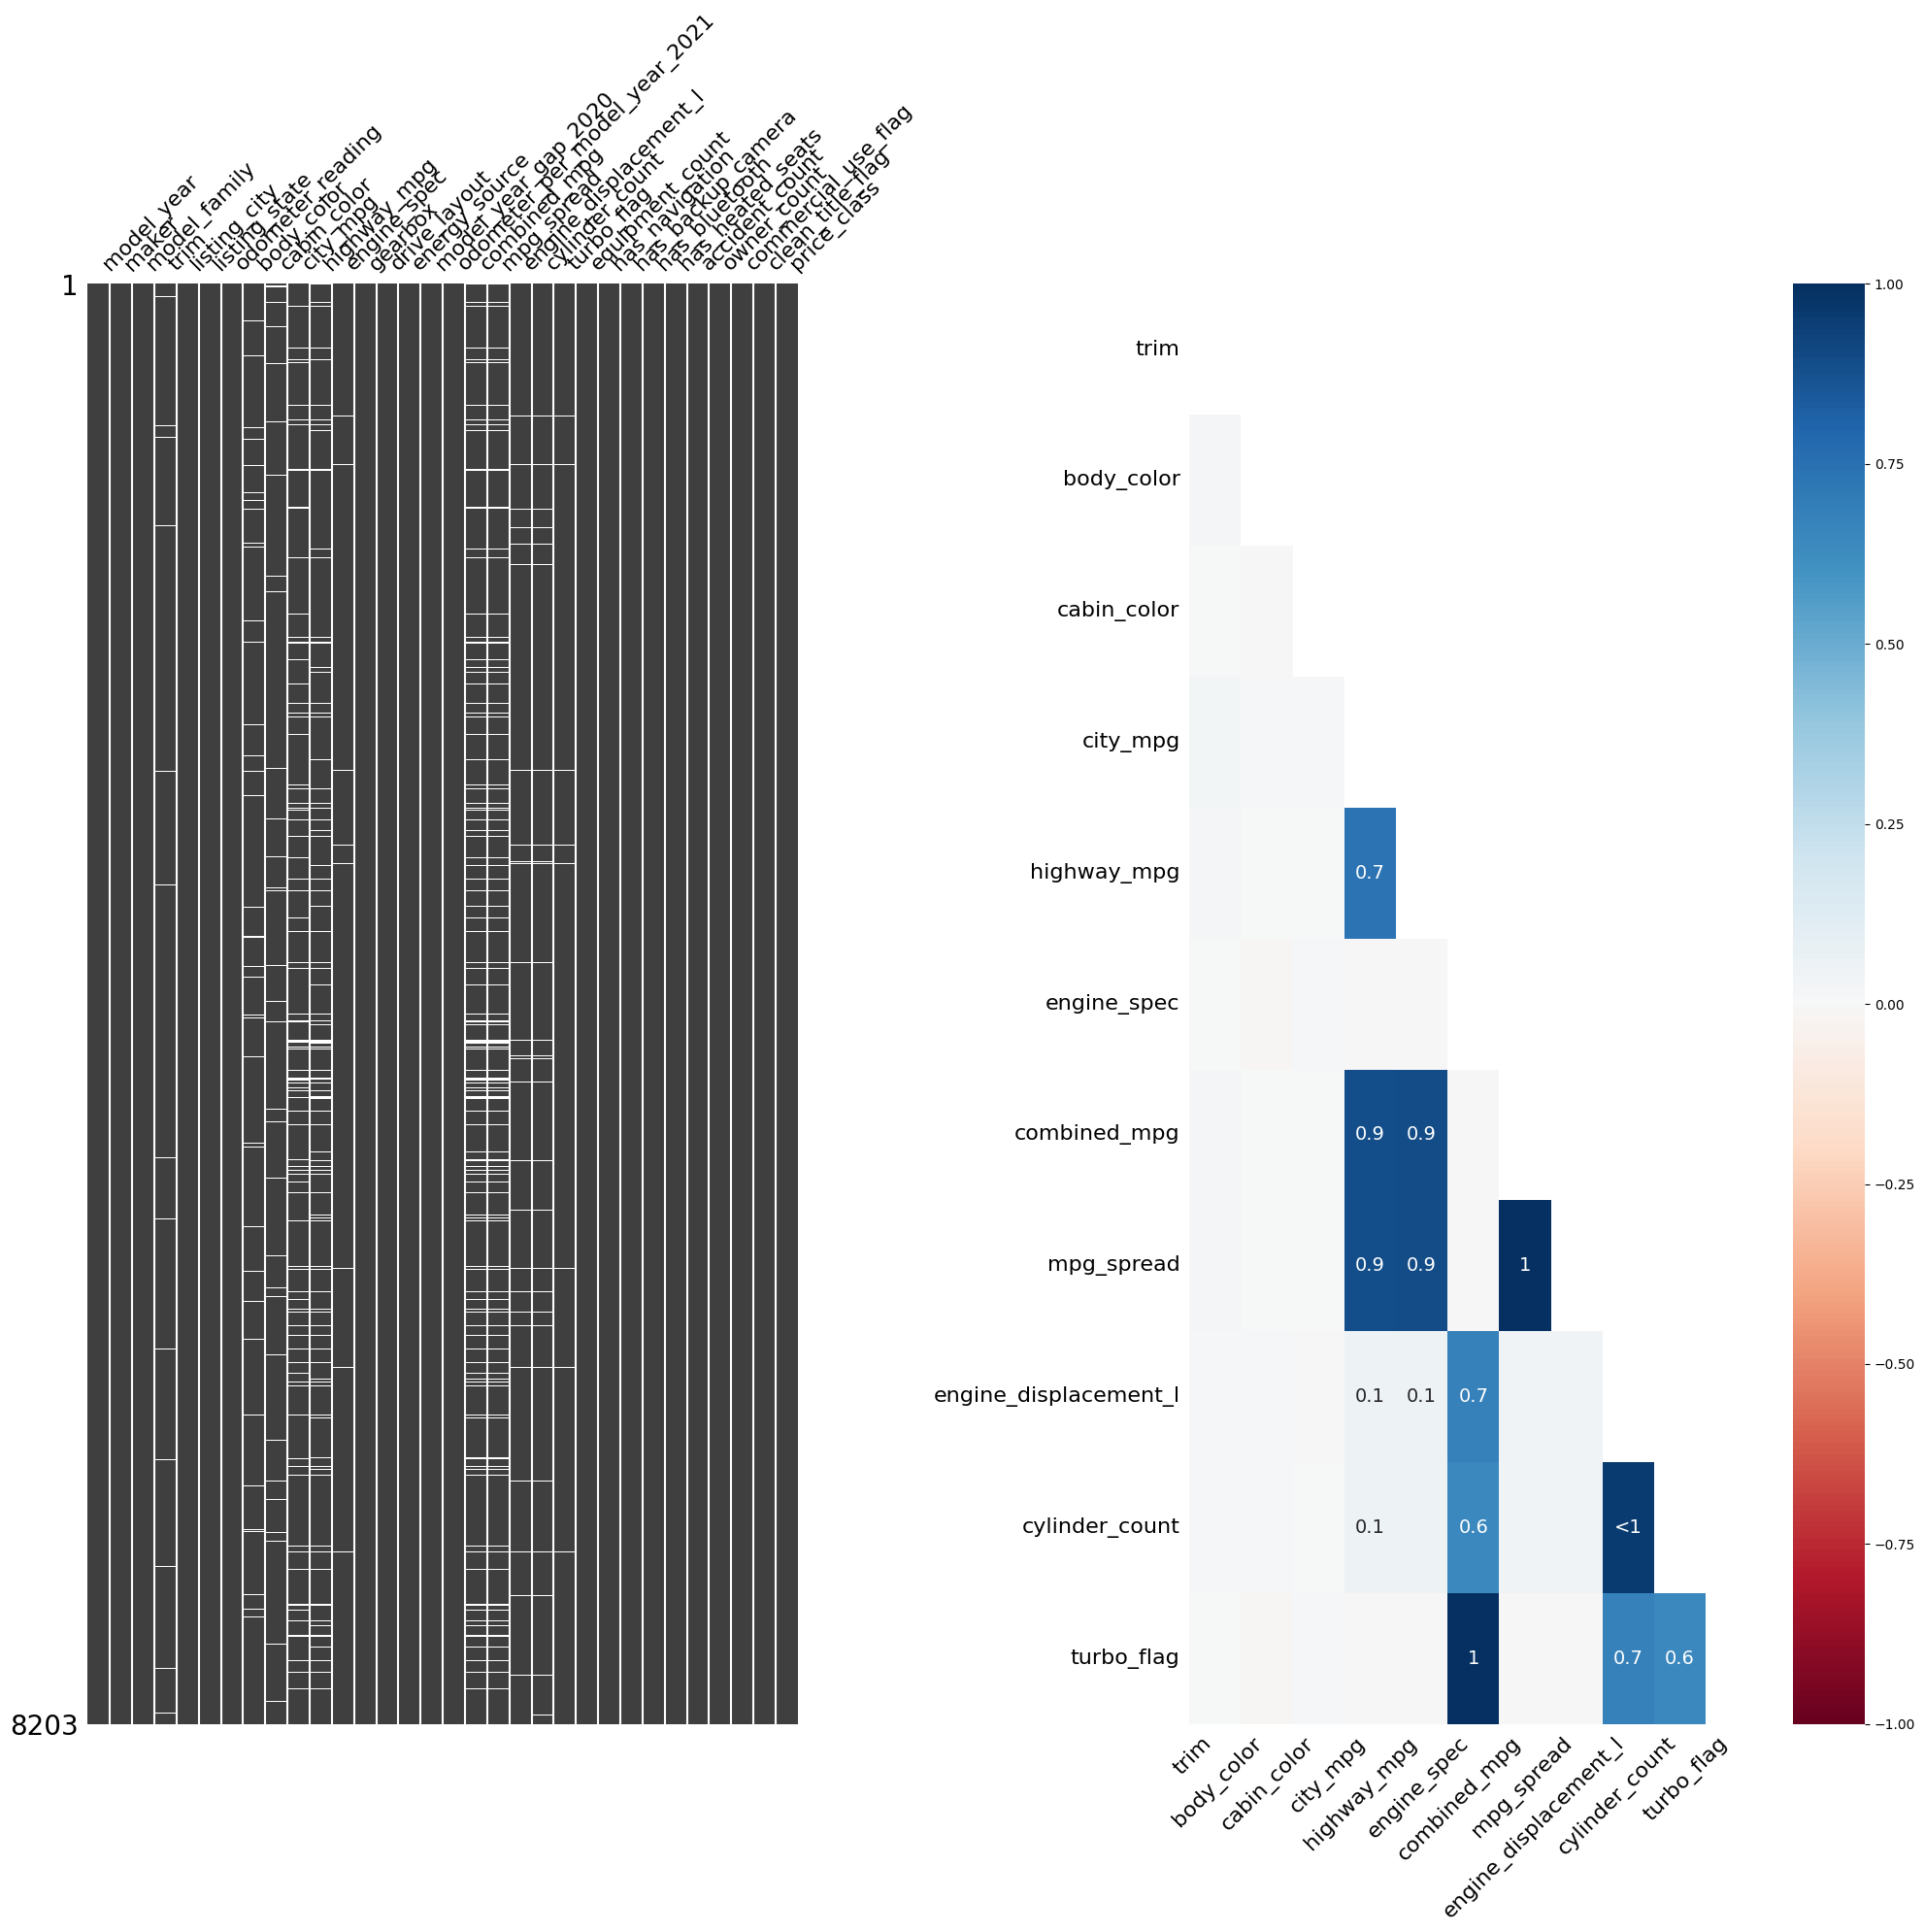

In [32]:
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

fig,ax = plt.subplots(1,2,figsize=(20,20))
msno.matrix(df_train, ax=ax[0])
msno.heatmap(df_train, ax=ax[1])
plt.tight_layout()

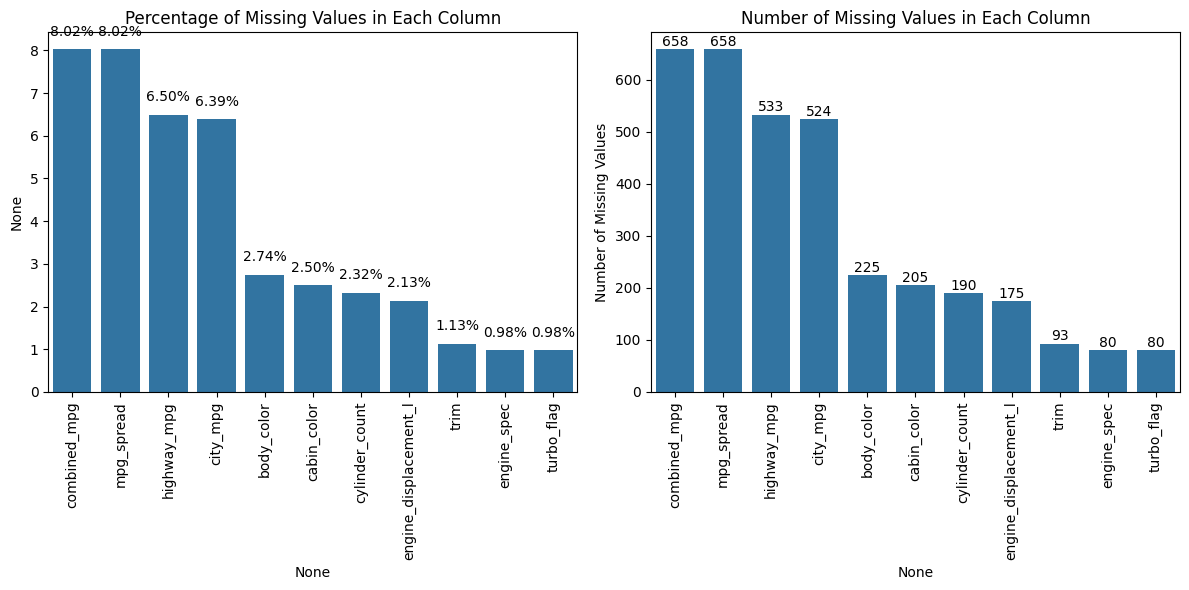

In [33]:
missing_values = df_train.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_percentage = (missing_values / len(df_train)) * 100

fig,ax = plt.subplots(1,2,figsize=(12,6))
sns.barplot(x=missing_values.index, y=missing_percentage, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
for i, v in enumerate(missing_percentage):
    ax[0].text(i, v + 0.25, f"{v:.2f}%", ha='center', va='bottom')
ax[0].set_title("Percentage of Missing Values in Each Column")

sns.barplot(x=missing_values.index, y=missing_values, ax=ax[1])
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
for i, v in enumerate(missing_values):
    ax[1].text(i, v + 0.25, f"{v}", ha='center', va='bottom')
ax[1].set_title("Number of Missing Values in Each Column")
ax[1].set_ylabel("Number of Missing Values")

plt.tight_layout()

## Distribution Analysis

In [34]:
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns


discrete_cols = ["model_year", "model_year_gap_2020", "cylinder_count", "turbo_flag", "equipment_count", "has_navigation", "has_bluetooth", "has_backup_camera", "has_heated_seats", "accident_count", "owner_count", "commercial_use_flag", "clean_title_flag", "price_class", "mpg_spread"]
continuous_cols = [col for col in num_cols if col not in discrete_cols]

n = len(continuous_cols)
print(f"Number of Numerical Columns: {n}")
print("Continuous Columns:")
for col in continuous_cols:
    print(f"- {col}")

print("Discrete Columns:")
for col in discrete_cols:
    print(f"- {col}")

Number of Numerical Columns: 6
Continuous Columns:
- odometer_reading
- city_mpg
- highway_mpg
- odometer_per_model_year_2021
- combined_mpg
- engine_displacement_l
Discrete Columns:
- model_year
- model_year_gap_2020
- cylinder_count
- turbo_flag
- equipment_count
- has_navigation
- has_bluetooth
- has_backup_camera
- has_heated_seats
- accident_count
- owner_count
- commercial_use_flag
- clean_title_flag
- price_class
- mpg_spread


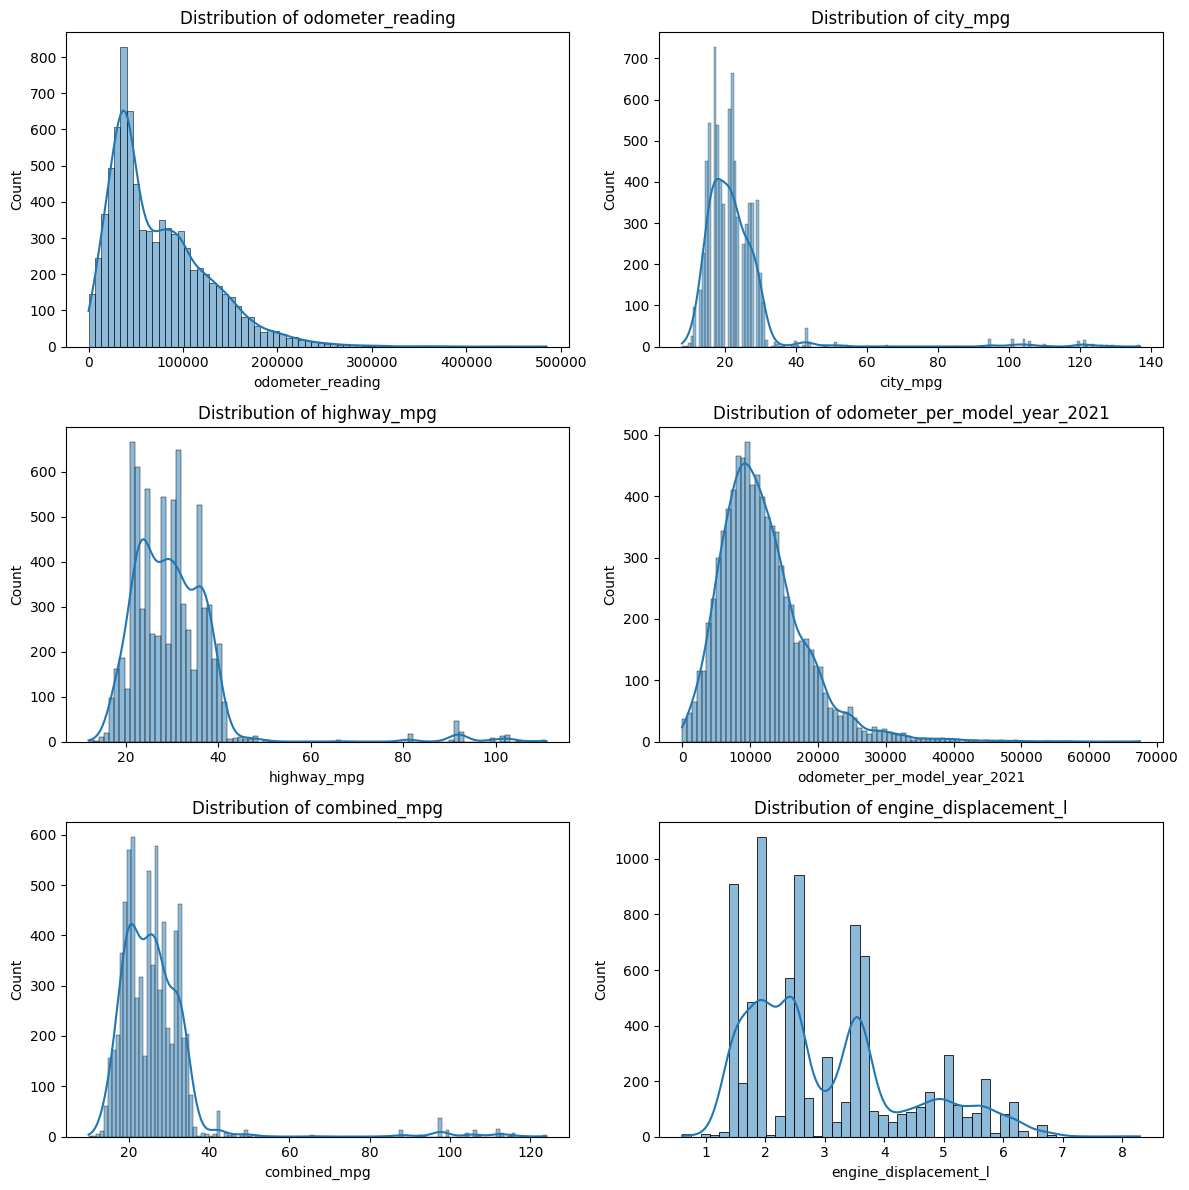

In [35]:
fig,ax = plt.subplots(nrows=(n+1)//2, ncols=2, figsize=(12, 4*((n+1)//2)))
for i, col in enumerate(continuous_cols):
    sns.histplot(df_train[col], kde=True, ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f"Distribution of {col}")

plt.tight_layout()


In [36]:
df_train.skew(numeric_only=True).sort_values(ascending=False)
high_skew_cols = df_train.skew(numeric_only=True).sort_values(ascending=False)
high_skew_cols = high_skew_cols[high_skew_cols > 1].index.tolist()
print("Columns with High Skewness (skew > 1):")
for col in high_skew_cols:
    print(f"- {col}: Skewness = {df_train[col].skew():.2f}")

Columns with High Skewness (skew > 1):
- city_mpg: Skewness = 5.59
- combined_mpg: Skewness = 4.84
- highway_mpg: Skewness = 3.78
- accident_count: Skewness = 2.62
- has_navigation: Skewness = 2.18
- owner_count: Skewness = 1.80
- odometer_per_model_year_2021: Skewness = 1.48
- commercial_use_flag: Skewness = 1.34
- model_year_gap_2020: Skewness = 1.26
- odometer_reading: Skewness = 1.22
- has_heated_seats: Skewness = 1.22
- turbo_flag: Skewness = 1.03


## Cardinality Analysis

In [37]:
cardinality = df_train.select_dtypes(include=['object']).nunique()
df_cardinality = pd.DataFrame({'Column': cardinality.index, 'Cardinality': cardinality.values})
df_cardinality = df_cardinality.sort_values(by='Cardinality', ascending=False)
df_cardinality

,Column,Cardinality
2,trim,1707
3,listing_city,1551
5,body_color,959
6,cabin_color,528
1,model_family,474
7,engine_spec,173
4,listing_state,50
0,maker,49
10,energy_source,7
9,drive_layout,4


In [38]:
OHE_cols = df_cardinality[df_cardinality['Cardinality'] <= 100]['Column'].tolist()
OHE_cols.remove("energy_source")  # Remove "energy_source" from OHE_cols
TE_cols = df_cardinality[df_cardinality['Cardinality'] > 100]['Column'].tolist()
TE_cols = TE_cols + ["energy_source"]  # Add "energy_source" to TE_cols

print("Columns suitable for One-Hot Encoding (OHE):")
for col in OHE_cols:
    print(f"- {col}")

print("\nColumns suitable for Target Encoding (TE):")
for col in TE_cols:
    print(f"- {col}")

Columns suitable for One-Hot Encoding (OHE):
- listing_state
- maker
- drive_layout
- gearbox

Columns suitable for Target Encoding (TE):
- trim
- listing_city
- body_color
- cabin_color
- model_family
- engine_spec
- energy_source


In [39]:
df_train.drop(columns=TE_cols, inplace=True)
df_test.drop(columns=TE_cols, inplace=True)

## Preprocessing

Lengkapi bagian ini sesuai dengan **Preprocessing Data** yang kalian lakukan

## Handling Missing

In [40]:
all_missing_cols = df_train.columns[df_train.isnull().any()].tolist()
print("Columns with Missing Values:")
for col in all_missing_cols:
    print(f"- {col}: {df_train[col].isnull().sum()} missing values - {(df_train[col].isnull().sum() / len(df_train)) * 100:.2f}% - {df_train[col].dtype}")


Columns with Missing Values:
- city_mpg: 524 missing values - 6.39% - float64
- highway_mpg: 533 missing values - 6.50% - float64
- combined_mpg: 658 missing values - 8.02% - float64
- mpg_spread: 658 missing values - 8.02% - float64
- engine_displacement_l: 175 missing values - 2.13% - float64
- cylinder_count: 190 missing values - 2.32% - float64
- turbo_flag: 80 missing values - 0.98% - float64


In [41]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

MAR = ["city_mpg", "city_mpg"]
Imputer = IterativeImputer(max_iter=10, random_state=SEED)
MAR_imputed = Imputer.fit_transform(df_train[MAR])
df_test[MAR] = Imputer.transform(df_test[MAR])
df_train[MAR] = MAR_imputed

for col in all_missing_cols:
    if df_train[col].dtype == 'object':
        df_train[col].fillna(df_train[col].mode()[0], inplace=True)
        df_test[col].fillna(df_test[col].mode()[0], inplace=True)
    else:
        median_value = df_train[col].median()
        df_train[col].fillna(median_value, inplace=True)
        df_test[col].fillna(median_value, inplace=True)

In [42]:
df_train.isnull().sum().sum(), df_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

## Handling Categorical

In [43]:
cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()

df_train = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)
df_test = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

In [44]:
df_test

,model_year,odometer_reading,city_mpg,highway_mpg,model_year_gap_2020,odometer_per_model_year_2021,combined_mpg,mpg_spread,engine_displacement_l,cylinder_count,...,listing_state_UT,listing_state_VA,listing_state_VT,listing_state_WA,listing_state_WI,listing_state_WY,gearbox_Manual,drive_layout_AWD,drive_layout_FWD,drive_layout_RWD
id,,,,,,,,,,,,,,,,,,,,,
8151,2016,24955,13.000000,21.0,4,4991.00,17.0,8.0,2.5,4.0,...,False,False,False,False,False,False,False,False,False,True
5620,2007,141920,12.000000,18.0,13,10137.14,15.0,6.0,2.5,4.0,...,False,False,False,False,False,False,False,False,False,False
12,2012,134502,22.000000,29.0,8,14944.67,25.5,7.0,2.5,4.0,...,False,False,False,False,False,False,False,True,False,False
8027,2004,38638,18.000000,25.0,16,2272.82,21.5,7.0,2.5,4.0,...,False,False,False,False,False,False,False,True,False,False
2450,2018,23931,16.000000,22.0,2,7977.00,19.0,6.0,2.5,4.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3004,2011,67618,15.000000,21.0,9,6761.80,18.0,6.0,3.7,6.0,...,False,False,False,False,False,False,False,False,False,False
4574,2010,34467,12.000000,19.0,10,3133.36,15.5,7.0,6.0,4.0,...,False,False,False,False,False,False,False,True,False,False
4090,2009,109000,22.956244,29.0,11,9083.33,25.0,8.0,5.7,8.0,...,False,False,False,False,False,False,False,False,False,False


# Feature Engineering

In [45]:
import numpy as np
import xgboost as xgb

print("Columns with High Skewness (skew > 1):")
for col in high_skew_cols:
    print(f"- {col}: Skewness = {df_train[col].skew():.2f}")

num_cols = df_test.select_dtypes(include=['int64', 'float64']).columns

def add_features(df):
    df["model_year_gap_2020"] = 2020 - df["model_year"]
    df["mpg_spread"] = df["highway_mpg"] - df["city_mpg"]

    # spamming feature interaction
    # for col in num_cols:
    #     if col not in ["model_year", "highway_mpg", "city_mpg", "cylinder_count"]:
    #         df[f"{col}_x_model_year"] = df[col] * df["model_year"]
    #         df[f"{col}_x_highway_mpg"] = df[col] * df["highway_mpg"]
    #         df[f"{col}_x_city_mpg"] = df[col] * df["city_mpg"]
    #         df[f"{col}_x_cylinder_count"] = df[col] * df["cylinder_count"]

    # spamming polynomial features
    for col in continuous_cols:
        df[f"{col}_squared"] = df[col] ** 2
        df[f"{col}_cubed"] = df[col] ** 3

    for col in high_skew_cols:
        df[f"{col}_log"] = df[col].apply(lambda x: np.log1p(x) if x > 0 else 0)


    return df

df_train = add_features(df_train)
df_test = add_features(df_test)

df_train.info()

Columns with High Skewness (skew > 1):
- city_mpg: Skewness = 5.78
- combined_mpg: Skewness = 5.07
- highway_mpg: Skewness = 3.93
- accident_count: Skewness = 2.62
- has_navigation: Skewness = 2.18
- owner_count: Skewness = 1.80
- odometer_per_model_year_2021: Skewness = 1.48
- commercial_use_flag: Skewness = 1.34
- model_year_gap_2020: Skewness = 1.26
- odometer_reading: Skewness = 1.22
- has_heated_seats: Skewness = 1.22
- turbo_flag: Skewness = 1.04
<class 'pandas.core.frame.DataFrame'>
Index: 8203 entries, 749 to 6076
Columns: 146 entries, model_year to turbo_flag_log
dtypes: bool(101), float64(30), int64(15)
memory usage: 3.7 MB


In [46]:
# from sklearn.feature_selection import RFE
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier

# model = RandomForestClassifier(n_estimators=100, random_state=SEED)
# X_train, X_val, y_train, y_val = train_test_split(df_train.drop(columns=[TARGET]), df_train[TARGET], test_size=0.2, random_state=SEED)
# rfe = RFE(estimator=model, n_features_to_select=50)
# rfe.fit(X_train, y_train)
# rfe.support_

In [47]:
# selected_features = df_train.drop(columns=[TARGET]).columns[rfe.support_].tolist()
# print("Selected Features after RFECV:")
# for feature in selected_features:
#     print(f"- {feature}")

# df_train = df_train[selected_features + [TARGET]]
# df_test = df_test[selected_features]

In [48]:
train_cols = set(df_train.drop(columns=[TARGET]).columns)
test_cols = set(df_test.columns)

train_only_cols = train_cols - test_cols

for col in train_only_cols:
    if col != TARGET:
        df_train.drop(columns=[col], inplace=True)

In [49]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold

# model = xgb.XGBClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=SEED,
#     use_label_encoder=False,
#     eval_metric='mlogloss'
# )

# model = lgb.LGBMClassifier(
#     n_estimators=200,
#     max_depth=10,
#     learning_rate=0.01,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=SEED,
#     objective='multiclass',
#     num_class=len(df_train[TARGET].unique())
# )

def add_xgb_features(df):
    X = df.drop(columns=[TARGET])
    y = df[TARGET]

    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    xgb_features = np.zeros((X.shape[0], 1))

    for train_index, val_index in kf.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        model.fit(X_train, y_train)
        xgb_features[val_index] = model.predict_proba(X_val)[:, 1].reshape(-1, 1)

    df["xgb_feature"] = xgb_features
    return df

def add_xgb_features_test(df_train, df_test):
    X = df_test
    y = df_train[TARGET]
    model.fit(df_train.drop(columns=[TARGET, "xgb_feature"]), y)
    xgb_features = model.predict_proba(X)[:, 1].reshape(-1, 1)
    df_test["xgb_feature"] = xgb_features
    return df_test

# df_train = add_xgb_features(df_train)

df_train_cols = set(df_train.columns)
df_test_cols = set(df_test.columns)
missing_cols_in_test = df_train_cols - df_test_cols
print("Columns in train but not in test:")
for col in missing_cols_in_test:
    print(f"- {col}")

# df_test = add_xgb_features_test(df_train, df_test)
# df_train

Columns in train but not in test:
- price_class


In [50]:
X_train, X_val, y_train, y_val = train_test_split(df_train.drop(columns=[TARGET]), df_train[TARGET], test_size=0.2, random_state=SEED)


## Modeling 

**DILARANG MENGUBAH CODE!!!!!!!!!!!!**, sesuaikan semua varible yang dibutuhkan.

**Pastikan sudah memiliki variable berikut:**
`X_train, X_val, y_train, y_val -> df_train`

In [51]:
# Modeling using Decision Tree

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_pred)}")
print(f"Precision: {precision_score(y_val, y_pred, average='macro', zero_division=0)}")
print(f"Recall: {recall_score(y_val, y_pred, average='macro', zero_division=0)}")
print(f"F1: {f1_score(y_val, y_pred, average='macro', zero_division=0)}")
print(classification_report(y_val, y_pred, zero_division=0))

Accuracy: 0.7867154174283973
Precision: 0.7868045767413588
Recall: 0.7862969998718953
F1: 0.7865211121966338
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       533
           1       0.69      0.69      0.69       544
           2       0.83      0.84      0.84       564

    accuracy                           0.79      1641
   macro avg       0.79      0.79      0.79      1641
weighted avg       0.79      0.79      0.79      1641



In [52]:
from sklearn.model_selection import cross_val_score
cross_val_scores = cross_val_score(model, df_train.drop(columns=[TARGET]), df_train[TARGET], cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

Cross-Validation Accuracy Scores: [0.80255941 0.80865326 0.80560634 0.79817073 0.7847561 ]
Mean Cross-Validation Accuracy: 0.7999491684130735


# Submission

**DILARANG MENGUBAH CODE!!!!!!!!!!!**

**Pastikan memiliki variable berikut:**
`X_test -> df_test`

In [53]:
id = df_test.index
X_test = df_test.copy()
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)

In [54]:
y_test = model.predict(X_test)
submission_df = pd.DataFrame({'id': id, 'price': y_test})
submission_df.to_csv('submission.csv', index=False)